In [31]:
import os
from json.decoder import NaN

import dill
import numpy as np
import pandas as pd
# import plotly.graph_objects as go
from numpy.ma.core import clip
from sklearn.metrics import r2_score
from IPython.display import display
from sympy.physics.control.control_plots import matplotlib

from ecoli.library.schema import bulk_name_to_idx

os.chdir(os.path.expanduser('~/vivarium-ecoli/'))
os.makedirs('notebooks/cofactors/buffer_figures', exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────────────
AVOGADRO = 6.02214076e23                                # molecules / mol
CELL_VOLUME_FL = {"Minimal": 1.44983, "Rich": 3.073264}  # femtolitres
TARGET_METALS  = ["FE", "ZN", "MN", "CU", "MO", "NI", "CO"]

# ── Plot style ────────────────────────────────────────────────────────────────
COLORS  = {"Minimal": "steelblue", "Rich": "tomato"}
SYMBOLS = {"Minimal": "circle",    "Rich": "diamond"}

In [32]:
# ── Helper functions ──────────────────────────────────────────────────────────
def atoms_to_M(atoms: float, vol_fL: float) -> float:
    """Convert atoms/cell → mol/L (plain float, no unit objects)."""
    return float(atoms) / (AVOGADRO * vol_fL * 1e-15)

def M_to_atoms(conc:float, vol_fL: float) -> float:
    """Convert concentration in M (mol/L) to atoms/cell"""
    return conc * AVOGADRO * vol_fL * 1e-15

def load_sim(folder_path: str):
    """Load simulation output; return (bulk DataFrame, metabolism step agent)."""
    output = np.load(folder_path + '0_output.npy', allow_pickle=True).item()
    output = output['agents']['0']
    bulk   = pd.DataFrame(output['bulk'])
    with open(folder_path + 'agent_steps.pkl', 'rb') as fh:
        agent = dill.load(fh)
    metabolism = agent['ecoli-metabolism-redux-classic']
    return bulk, metabolism


def get_sim_buf_concs(
    bulk, metabolism, buffers: list[str], vol_fL: float
) -> pd.Series:
    """
    Return mean steady-state concentrations (M) for *buffers* as a Series
    indexed by molecule name.
    """
    idx        = bulk_name_to_idx(buffers, metabolism.bulk_ids)
    mean_cnts  = pd.DataFrame(bulk[idx]).mean(axis=0).values
    concs_M    = mean_cnts / (AVOGADRO * vol_fL * 1e-15)
    return pd.Series(concs_M, index=buffers, name='conc_M', dtype=float)

---
## 1. Deficit DataFrames

$$\text{deficit}_\text{M} = [\text{Metal}]_{\text{ICP}} - [\text{Metal}]_{\text{sim}}$$

Uncertainty propagated in quadrature from ICP-MS and simulation standard deviations.

In [33]:
raw = pd.read_csv('notebooks/cofactors/data/metals_plot_data.csv')
raw['Element'] = raw['Element'].str.replace('"', '').str.strip()
raw['Medium']  = raw['Medium'].str.replace('"', '').str.strip()
raw = raw[raw['Element'].isin(TARGET_METALS)].copy()

# Convert atoms/cell → M for both conditions
for cond in ['Minimal', 'Rich']:
    mask = raw['Medium'] == cond
    vol  = CELL_VOLUME_FL[cond]

    raw.loc[mask, 'icp_M']   = (raw.loc[mask, 'Atoms/cell (experiment)']
                                .apply(lambda x: atoms_to_M(x, vol)))
    raw.loc[mask, 'sim_M']   = (raw.loc[mask, 'Atoms/cell (simulation)']
                                .apply(lambda x: atoms_to_M(x, vol)))

    deficit_atoms = (
        raw.loc[mask, 'Atoms/cell (experiment)']
        - raw.loc[mask, 'Atoms/cell (simulation)']
    )
    deficit_err_atoms = np.sqrt(
        raw.loc[mask, 'Atoms/cell (experiment), stddev'] ** 2
        + raw.loc[mask, 'Atoms/cell (simulation), stddev'] ** 2
    )
    raw.loc[mask, 'deficit_M']     = deficit_atoms.apply(lambda x: atoms_to_M(x, vol))
    raw.loc[mask, 'deficit_M_err'] = deficit_err_atoms.apply(lambda x: atoms_to_M(x, vol))

DEFICIT_COLS = ['icp_M', 'sim_M', 'deficit_M', 'deficit_M_err']

# ── Split by medium, Element as index ────────────────────────────────────────
deficit_minimal = (
    raw[raw['Medium'] == 'Minimal']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)
deficit_rich = (
    raw[raw['Medium'] == 'Rich']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)

In [34]:
print('=== deficit_minimal (Element × 4) ===')
display(deficit_minimal.style.format('{:.3e}'))

print('\n=== deficit_rich (Element × 4) ===')
display(deficit_rich.style.format('{:.3e}'))

=== deficit_minimal (Element × 4) ===


,icp_M,sim_M,deficit_M,deficit_M_err
Element,,,,
FE,2.061e-04,3.065e-04,-1.004e-04,3.430e-05
CU,8.992e-06,9.729e-06,-7.371e-07,1.512e-06
CO,5.957e-07,0.000e+00,5.957e-07,1.145e-06
NI,4.329e-06,7.835e-07,3.546e-06,1.154e-06
ZN,2.288e-04,2.463e-04,-1.742e-05,6.533e-05
MO,4.562e-06,2.508e-06,2.054e-06,1.188e-06



=== deficit_rich (Element × 4) ===


,icp_M,sim_M,deficit_M,deficit_M_err
Element,,,,
CU,4.732e-05,8.219e-06,3.910e-05,1.588e-05
MO,5.834e-06,1.861e-06,3.972e-06,5.808e-07
NI,1.751e-06,6.942e-07,1.057e-06,5.487e-07
ZN,2.159e-04,1.930e-04,2.290e-05,4.917e-05
CO,2.397e-07,0.000e+00,2.397e-07,5.403e-08
MN,2.526e-05,3.750e-05,-1.224e-05,7.271e-06
FE,3.281e-04,2.673e-04,6.076e-05,7.159e-05


---
## 2. Load Simulation

In [35]:
# bulk_basal, metabolism = load_sim(
#     'out_cyrus/basal/metabolism_classic_1500_2026-03-24/'
# )
# bulk_rich, _ = load_sim(
#     'out_cyrus/with_aa/metabolism_classic_1500_2026-03-24/'
# )
# print('Simulation loaded.  bulk_basal shape:', bulk_basal.shape,
#       ' | bulk_rich shape:', bulk_rich.shape)

---
## 3. Buffer Constants

Columns 0–1: literature free-metal concentrations (M)
Columns 2–3: experimentally measured *total* buffered metal concentrations ± std (M9/Minimal media)
Columns 4+: stability constants log(β) for each ligand

In [36]:
buf_raw = pd.read_csv('notebooks/cofactors/data/buffer_constants.csv', index_col=0)
buf_raw.index.name = 'Element'

# ── Free metal concentrations (literature, M) ─────────────────────────────
free_metal_minimal = buf_raw.iloc[:, 0].astype(float).rename('free_M')  # M9 / Minimal
free_metal_rich    = buf_raw.iloc[:, 1].astype(float).rename('free_M')  # LB / Rich

# ── Measured total buffered concentrations (M9 only) ──────────────────────
# divide by 2 to account for 50% cytosol volume of the measurements
meas_buf_minimal = buf_raw.iloc[:, 2:4].astype(float).copy() / 2
meas_buf_minimal.columns = ['measured_M', 'measured_std_M']

# ── Stability constants log(β): Element × buffer ──────────────────────────
stability = buf_raw.iloc[:, 4:].astype(float).copy()
stability_ub = stability + 1
stability_lb = stability - 1


# ── Look-up dicts (same structure as original) ────────────────────────────
buffer_to_metal_ub: dict[str, dict[str, float]] = {}   # buf  → {metal: logβ}
metal_to_buffer_ub: dict[str, dict[str, float]] = {}   # metal → {buf: logβ}
buffer_to_metal_lb: dict[str, dict[str, float]] = {}   # buf  → {metal: logβ}
metal_to_buffer_lb: dict[str, dict[str, float]] = {}   # metal → {buf: logβ}

for buf in stability.columns:
    row_ub = stability_ub[buf].dropna()
    row_lb = stability_lb[buf].dropna()
    if not row_ub.empty:
        buffer_to_metal_ub[buf] = row_ub.to_dict()
        buffer_to_metal_lb[buf] = row_lb.to_dict()

for buf, metals_dict in buffer_to_metal_ub.items():
    for metal, logbeta in metals_dict.items():
        metal_to_buffer_ub.setdefault(metal, {})[buf] = logbeta

for buf, metals_dict in buffer_to_metal_lb.items():
    for metal, logbeta in metals_dict.items():
        metal_to_buffer_lb.setdefault(metal, {})[buf] = logbeta

ALL_BUFFERS = list(buffer_to_metal_ub.keys())
ALL_METALS  = list(free_metal_minimal.index)

In [37]:
print('=== free_metal_minimal (Element Series, M) ===')
display(free_metal_minimal.to_frame().style.format('{:.3e}'))

print('\n=== meas_buf_minimal (Element × 2, M) ===')
display(meas_buf_minimal.style.format('{:.3e}'))

print('\n=== stability (Element × buffer, log β) ===')
display(stability)

print('\nBuffers with stability data:', ALL_BUFFERS)

=== free_metal_minimal (Element Series, M) ===


,free_M
Element,
MG,2.700e-03
MN,2.080e-06
FE,6.180e-08
CO,2.420e-10
NI,2.560e-12
CU,1.460e-20
ZN,1.040e-11



=== meas_buf_minimal (Element × 2, M) ===


,measured_M,measured_std_M
Element,,
MG,1.490e-02,1.145e-03
MN,7.000e-07,3.500e-07
FE,4.000e-05,1.000e-05
CO,nan,nan
NI,7.500e-06,1.000e-06
CU,5.000e-06,1.000e-06
ZN,6.500e-06,1.500e-06



=== stability (Element × buffer, log β) ===


,GLUTATHIONE[c],CYS[c],HIS[c],OXIDIZED-GLUTATHIONE[c],L-ASPARTATE[c],MET[c],L-ALPHA-ALANINE[c],LEU[c],VAL[c],GLY[c],TRP[c],ATP[c],CIT[c]
Element,,,,,,,,,,,,,
MG,NaN,2.75,NaN,NaN,2.40,NaN,1.96,NaN,NaN,1.66,NaN,4.03,3.44
MN,2.70,4.75,3.240000,NaN,3.91,2.77,2.43,2.30,2.32,2.27,2.54,4.76,3.79
FE,5.10,6.20,5.883093,NaN,4.34,3.24,3.54,3.42,3.39,NaN,NaN,5.18,4.56
CO,NaN,8.14,6.700000,NaN,5.90,4.17,4.32,4.49,4.24,4.64,4.47,4.60,4.90
NI,7.37,9.60,8.430000,9.08,7.16,5.27,5.26,5.33,5.09,5.59,5.35,4.86,5.30
CU,11.60,11.10,9.820000,13.37,8.75,7.68,7.94,7.97,7.96,7.99,8.01,6.34,8.22
ZN,7.98,9.11,6.350000,7.60,5.82,4.30,4.54,4.51,4.47,4.87,4.54,5.16,4.64



Buffers with stability data: ['GLUTATHIONE[c]', 'CYS[c]', 'HIS[c]', 'OXIDIZED-GLUTATHIONE[c]', 'L-ASPARTATE[c]', 'MET[c]', 'L-ALPHA-ALANINE[c]', 'LEU[c]', 'VAL[c]', 'GLY[c]', 'TRP[c]', 'ATP[c]', 'CIT[c]']


---
## 4. Simulation Buffer Concentrations

Mean steady-state concentrations across all simulation time-steps, converted to mol/L.

In [38]:
# sim_buf_minimal = get_sim_buf_concs(
#     bulk_basal, metabolism, ALL_BUFFERS, CELL_VOLUME_FL['Minimal']
# )
# sim_buf_rich = get_sim_buf_concs(
#     bulk_rich, metabolism, ALL_BUFFERS, CELL_VOLUME_FL['Rich']
# )

sim_buf_minimal = pd.read_csv("notebooks/cofactors/data/sim_buf_minimal.csv", index_col=0)
sim_buf_rich = pd.read_csv("notebooks/cofactors/data/sim_buf_rich.csv", index_col=0)
# ── Display side by side ───────────────────────────────────────────────────
# sim_buf_display = pd.concat(
#     [sim_buf_minimal.rename('Minimal'), sim_buf_rich.rename('Rich')], axis=1
# )
# print('=== sim_buf_minimal / sim_buf_rich (buffer Series, M) ===')
# display(sim_buf_display.style.format('{:.3e}'))

---
## 5. Approach 1 – Competition Model

**Step 1** – free buffer concentration (accounting for metal competition)

$$[L_\text{free}] = \frac{[L_\text{total}]}{1 + \sum_M K_{A,M} \cdot [M_\text{free}]}$$

**Step 2** – total buffered metal concentration

$$[M_\text{buffered}] = [M_\text{free}] \cdot \left(1 + \sum_L K_{A,L} \cdot [L_\text{free}]\right)$$

> **Note:** Following the original analysis, `free_metal_minimal` is used for the competition factor in *both* conditions.  Only the simulation-derived buffer concentrations (`sim_buf_minimal` vs `sim_buf_rich`) differ.

In [39]:
def estimate_buffered_competition(
    metals: list[str],
    free_metal: pd.Series,
    sim_buf: pd.Series,
    metal_to_buffer: dict,
    buffer_to_metal: dict,
) -> pd.Series:
    free_metal_d = free_metal.to_dict()
    sim_buf_d    = sim_buf.to_dict()

    # ── Step 1: free buffer concentrations ───────────────────────────────────
    #
    # Ligand mass balance (1:1 stoichiometry only):
    #   [L]_total = [L]_free + Σ_M β_ML * [M]_free * [L]_free
    #             = [L]_free * (1 + Σ_M β_ML * [M]_free)
    #
    #   → [L]_free = [L]_total / (1 + Σ_M β_ML * [M]_free)

    free_buf: dict[str, float] = {}
    for buf in set(buffer_to_metal):
        total = sim_buf_d.get(buf, 0.0)
        B = 1.0
        for m, lb in buffer_to_metal.get(buf, {}).items():
            B += 10 ** lb * free_metal_d.get(m, 0.0)
        free_buf[buf] = total / B

    # ── Step 2: total (free + small-molecule-chelated) metal ─────────────────
    #
    # Metal mass balance (1:1 stoichiometry only):
    #   [M]_total = [M]_free * (1 + Σ_L β_ML * [L]_free)

    result: dict[str, float] = {}
    for metal in metals:
        free_m = free_metal_d.get(metal, 0.0)
        comp   = sum(
            10 ** lb * free_buf.get(buf, 0.0)
            for buf, lb in metal_to_buffer.get(metal, {}).items()
        )
        result[metal] = free_m * (1 + comp)

    return pd.Series(result, name='est_competition_M', dtype=float)

In [40]:
est_competition_minimal_lb = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_minimal,
    metal_to_buffer_lb, buffer_to_metal_lb,
)
est_competition_minimal_ub = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_minimal,
    metal_to_buffer_ub, buffer_to_metal_ub,
)
est_competition_rich_lb = estimate_buffered_competition(
    ALL_METALS, free_metal_rich, sim_buf_rich,
    metal_to_buffer_lb, buffer_to_metal_lb,
)
est_competition_rich_ub = estimate_buffered_competition(
    ALL_METALS, free_metal_rich, sim_buf_rich,
    metal_to_buffer_ub, buffer_to_metal_ub,
)

print('=== est_competition_minimal / est_competition_rich (Element Series, M) ===')
display(
    pd.concat([
        est_competition_minimal_lb.rename('Minimal Lower Bound'),
        est_competition_minimal_ub.rename('Minimal Upper Bound'),
        est_competition_rich_lb.rename('Rich Lower Bound'),
        est_competition_rich_ub.rename('Rich Upper Bound'),
    ], axis=1).style.format('{:.3e}')
)

=== est_competition_minimal / est_competition_rich (Element Series, M) ===


,Minimal Lower Bound,Minimal Upper Bound,Rich Lower Bound,Rich Upper Bound
MG,2.700e-03,2.700e-03,1.000e-03,1.000e-03
MN,2.080e-06,2.080e-06,7.000e-06,7.000e-06
FE,6.180e-08,6.180e-08,1.900e-06,1.900e-06
CO,2.420e-10,2.420e-10,7.000e-11,7.000e-11
NI,2.560e-12,2.560e-12,1.300e-13,1.300e-13
CU,1.460e-20,1.460e-20,4.500e-20,4.500e-20
ZN,1.040e-11,1.040e-11,9.400e-12,9.400e-12


---
## 6. Approach 2 – Simplified Model

Same as Approach 1 but the free buffer concentration equals the total simulation concentration (no cross-metal competition correction for ligand occupancy):

$$[M_\text{buffered}] = [M_\text{free}] \cdot \left(1 + \sum_L K_{A,L} \cdot [L_\text{total}]\right)$$

In [41]:
def estimate_buffered_simplified(
    metals: list[str],
    free_metal: pd.Series,
    sim_buf: pd.Series,
    metal_to_buffer: dict,
) -> pd.Series:
    """
    Simplified model: uses total (not free) buffer concentrations.
    1:1 stoichiometry only.
    """
    free_metal_d = free_metal.to_dict()
    sim_buf_d    = sim_buf.to_dict()

    result: dict[str, float] = {}
    for metal in metals:
        free_m = free_metal_d.get(metal, 0.0)
        comp   = sum(
            10 ** lb * sim_buf_d.get(buf, 0.0)
            for buf, lb in metal_to_buffer.get(metal, {}).items()
        )
        result[metal] = free_m * (1 + comp)

    return pd.Series(result, name='est_simplified_M', dtype=float)

In [42]:
est_simplified_minimal_lb = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_lb
)
est_simplified_minimal_ub = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_ub
)
est_simplified_rich_lb = estimate_buffered_simplified(
    ALL_METALS, free_metal_rich, sim_buf_rich, metal_to_buffer_lb
)
est_simplified_rich_ub = estimate_buffered_simplified(
    ALL_METALS, free_metal_rich, sim_buf_rich, metal_to_buffer_ub
)

print('=== est_simplified_minimal / est_simplified_rich (Element Series, M) ===')
display(
    pd.concat([
        est_simplified_minimal_lb.rename('Minimal Lower Bound'),
        est_simplified_minimal_ub.rename('Minimal Upper Bound'),
        est_simplified_rich_lb.rename('Rich Lower Bound'),
        est_simplified_rich_ub.rename('Rich Upper Bound'),
    ], axis=1).style.format('{:.3e}')
)

=== est_simplified_minimal / est_simplified_rich (Element Series, M) ===


,Minimal Lower Bound,Minimal Upper Bound,Rich Lower Bound,Rich Upper Bound
MG,2.700e-03,2.700e-03,1.000e-03,1.000e-03
MN,2.080e-06,2.080e-06,7.000e-06,7.000e-06
FE,6.180e-08,6.180e-08,1.900e-06,1.900e-06
CO,2.420e-10,2.420e-10,7.000e-11,7.000e-11
NI,2.560e-12,2.560e-12,1.300e-13,1.300e-13
CU,1.460e-20,1.460e-20,4.500e-20,4.500e-20
ZN,1.040e-11,1.040e-11,9.400e-12,9.400e-12


---
## 7. Combined Results Tables

Because every DataFrame is Element-indexed, assembling the full results is a single `pd.concat` — no merge, no groupby.

In [43]:
results_minimal = pd.concat(
    [
        deficit_minimal,
        meas_buf_minimal,
        est_competition_minimal_lb,
        est_competition_minimal_ub,
        est_simplified_minimal_lb,
        est_simplified_minimal_ub,
        free_metal_minimal,
    ],
    axis=1,
)

results_rich = pd.concat(
    [
        deficit_rich,
        est_competition_rich_lb,
        est_competition_rich_ub,
        est_simplified_rich_lb,
        est_simplified_rich_ub,
        free_metal_rich.rename('free_M_lit'),  # Minimal free-metal used for both
    ],
    axis=1,
)

print('=== results_minimal ===')
display(results_minimal.style.format('{:.3e}'))

print('\n=== results_rich ===')
display(results_rich.style.format('{:.3e}'))

=== results_minimal ===


,icp_M,sim_M,deficit_M,deficit_M_err,measured_M,measured_std_M,est_competition_M,est_competition_M,est_simplified_M,est_simplified_M,free_M
FE,2.061e-04,3.065e-04,-1.004e-04,3.430e-05,4.000e-05,1.000e-05,6.180e-08,6.180e-08,6.180e-08,6.180e-08,6.180e-08
CU,8.992e-06,9.729e-06,-7.371e-07,1.512e-06,5.000e-06,1.000e-06,1.460e-20,1.460e-20,1.460e-20,1.460e-20,1.460e-20
CO,5.957e-07,0.000e+00,5.957e-07,1.145e-06,nan,nan,2.420e-10,2.420e-10,2.420e-10,2.420e-10,2.420e-10
NI,4.329e-06,7.835e-07,3.546e-06,1.154e-06,7.500e-06,1.000e-06,2.560e-12,2.560e-12,2.560e-12,2.560e-12,2.560e-12
ZN,2.288e-04,2.463e-04,-1.742e-05,6.533e-05,6.500e-06,1.500e-06,1.040e-11,1.040e-11,1.040e-11,1.040e-11,1.040e-11
MO,4.562e-06,2.508e-06,2.054e-06,1.188e-06,nan,nan,nan,nan,nan,nan,nan
MG,nan,nan,nan,nan,1.490e-02,1.145e-03,2.700e-03,2.700e-03,2.700e-03,2.700e-03,2.700e-03
MN,nan,nan,nan,nan,7.000e-07,3.500e-07,2.080e-06,2.080e-06,2.080e-06,2.080e-06,2.080e-06



=== results_rich ===


,icp_M,sim_M,deficit_M,deficit_M_err,est_competition_M,est_competition_M,est_simplified_M,est_simplified_M,free_M_lit
CU,4.732e-05,8.219e-06,3.910e-05,1.588e-05,4.500e-20,4.500e-20,4.500e-20,4.500e-20,4.500e-20
MO,5.834e-06,1.861e-06,3.972e-06,5.808e-07,nan,nan,nan,nan,nan
NI,1.751e-06,6.942e-07,1.057e-06,5.487e-07,1.300e-13,1.300e-13,1.300e-13,1.300e-13,1.300e-13
ZN,2.159e-04,1.930e-04,2.290e-05,4.917e-05,9.400e-12,9.400e-12,9.400e-12,9.400e-12,9.400e-12
CO,2.397e-07,0.000e+00,2.397e-07,5.403e-08,7.000e-11,7.000e-11,7.000e-11,7.000e-11,7.000e-11
MN,2.526e-05,3.750e-05,-1.224e-05,7.271e-06,7.000e-06,7.000e-06,7.000e-06,7.000e-06,7.000e-06
FE,3.281e-04,2.673e-04,6.076e-05,7.159e-05,1.900e-06,1.900e-06,1.900e-06,1.900e-06,1.900e-06
MG,nan,nan,nan,nan,1.000e-03,1.000e-03,1.000e-03,1.000e-03,1.000e-03


---
## 8. Plots

### Helper: build long-form DataFrame for plotting (positive deficits only)

In [44]:
def build_plot_df(
    est_minimal_lb: pd.Series,
    est_minimal_ub: pd.Series,
    est_rich_lb: pd.Series,
    est_rich_ub: pd.Series,
    deficit_minimal: pd.DataFrame,
    deficit_rich: pd.DataFrame,
    positive_only: bool = True,
) -> pd.DataFrame:
    """
    Merge lb/ub buffered estimates with deficits into a long-form DataFrame.

    Columns: Medium, Element, est_buf_lb_M, est_buf_ub_M,
             est_buf_center_M, deficit_M, deficit_M_err
    """
    rows = []
    for cond, est_lb, est_ub, deficit_df in [
        ('Minimal', est_minimal_lb, est_minimal_ub, deficit_minimal),
        ('Rich',    est_rich_lb,    est_rich_ub,    deficit_rich),
    ]:
        for element in est_lb.index:
            if element not in deficit_df.index:
                continue
            deficit_val = deficit_df.loc[element, 'deficit_M']
            deficit_err = deficit_df.loc[element, 'deficit_M_err']
            if positive_only and deficit_val <= 0:
                continue
            lb = float(est_lb[element])
            ub = float(est_ub[element])
            rows.append({
                'Medium':            cond,
                'Element':           element,
                'est_buf_lb_M':      lb,
                'est_buf_ub_M':      ub,
                'est_buf_center_M':  (lb + ub) / 2,
                'deficit_M':         float(deficit_val),
                'deficit_M_err':     float(deficit_err),
            })
    return pd.DataFrame(rows)

### Plot 1 – Competition model: estimated buffered [Metal] vs. Estimated deficit

In [45]:
import polars as pl
import altair as alt

plot_df_comp = build_plot_df(
    est_competition_minimal_lb, est_competition_minimal_ub,
    est_competition_rich_lb,    est_competition_rich_ub,
    deficit_minimal, deficit_rich,
)

df = pl.from_pandas(plot_df_comp).with_columns([
    (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
    (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
    (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
    (pl.col("deficit_M")        * 1e6).alias("y_uM"),
    (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
])

DOMAIN_MIN = 1e-7   # just below your domain floor of 1e-6

# ── Log-axis label expression (10^n with Unicode superscripts) ────────────────
_log_label_unicode = (
    "datum.value > 0 ? '10' + "
    "replace(replace(replace(replace(replace(replace("
    "replace(replace(replace(replace(replace('' + "
    "round(log(datum.value)/LN10), '-','⁻'),'0','⁰'),'1','¹'),'2','²')"
    ",'3','³'),'4','⁴'),'5','⁵'),'6','⁶'),'7','⁷'),'8','⁸'),'9','⁹') : '0'"
)

df = df.with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

base = alt.Chart(df).encode(
)
x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

ref_df = pl.DataFrame({"v": [1e-6, 1e6]})  # for reference line y=x

ref_line = alt.Chart(ref_df).mark_line(strokeDash=[4,4], color="gray").encode(
    x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
)
x_bars = base.mark_errorbar(ticks=True).encode(
    x=alt.X("x_lb_uM:Q", scale=x_scale, title=""),
    x2="x_ub_uM:Q",
    y=alt.Y("y_uM:Q", scale=y_scale),
    color="Medium:N",
)
y_bars = base.mark_errorbar(ticks=True, clip=True).encode(
    x=alt.X("x_uM:Q"),
    y=alt.Y("y_lo_uM:Q",  scale=y_scale, title=""),   # explicit log scale + clamped lower
    y2=alt.Y2("y_hi_uM:Q"),
    color="Medium:N",
)
points = base.mark_point(filled=True, size=150, stroke='black', strokeWidth=1).encode(
    x=alt.X("x_uM:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("y_uM:Q", scale=y_scale, axis=_ax_y),
    color=alt.Color("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["steelblue","tomato"])),
    shape=alt.Shape("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["circle","diamond"])),
)
# 5. Text labels
labels = base.mark_text(dx=15, dy=-15, fontSize=12).encode(
    x=alt.X("x_uM:Q", scale=alt.Scale(type="log")),
    y=alt.Y("y_uM:Q", scale=alt.Scale(type="log")),
    text="Element:N",
)
chart = (ref_line + x_bars + y_bars + points + labels).properties(
    width=600, height=480,
    title="Buffered Metal Concentration vs. Deficit Fig1C – Competition Model"
).configure_axis(gridColor='#f3f6fa')
# chart.save('notebooks/cofactors/buffer_figures/buffered_metal_vs_deficit_competition.svg')
chart

alt.LayerChart(...)

In [46]:
M_to_atoms(est_competition_minimal_lb, CELL_VOLUME_FL['Minimal'])

MG    2.357392e+06
MN    1.816065e+03
FE    5.395808e+01
CO    2.112921e-01
NI    2.235157e-03
CU    1.274738e-11
ZN    9.080324e-03
Name: est_competition_M, dtype: float64

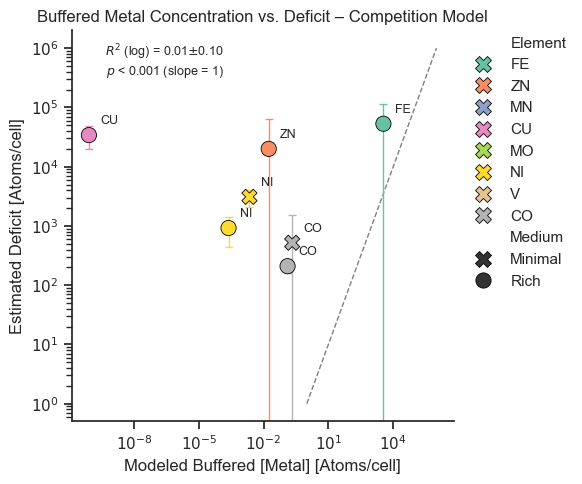

In [47]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import polars as pl

plot_df_comp = build_plot_df(
    M_to_atoms(est_competition_minimal_lb, CELL_VOLUME_FL['Minimal']),
    M_to_atoms(est_competition_minimal_ub, CELL_VOLUME_FL['Minimal']),
    M_to_atoms(est_competition_rich_lb, CELL_VOLUME_FL['Rich']),
    M_to_atoms(est_competition_rich_ub, CELL_VOLUME_FL['Rich']),
    M_to_atoms(deficit_minimal, CELL_VOLUME_FL['Minimal']),
    M_to_atoms(deficit_rich, CELL_VOLUME_FL['Minimal'])
)

# df = pl.from_pandas(plot_df_comp).with_columns([
#     (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
#     (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
#     (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
#     (pl.col("deficit_M")        * 1e6).alias("y_uM"),
#     (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
# ])

df = pl.from_pandas(plot_df_comp).with_columns([
    (pl.col("est_buf_center_M") ).alias("x_count"),
    (pl.col("est_buf_lb_M")).alias("x_lb_count"),
    (pl.col("est_buf_ub_M")).alias("x_ub_count"),
    (pl.col("deficit_M")).alias("y_count"),
    (pl.col("deficit_M_err")).alias("y_err_count"),
])


sns.set_theme(style="ticks")

plot_df = df.to_pandas()

# Build a consistent color map keyed by Element
elements = sorted(plot_df["Element"].unique())
elements = ['FE', 'ZN', 'MN', 'CU', 'MO', 'NI', 'V', 'CO',]
palette   = sns.color_palette("Set2", n_colors=len(elements))
color_map = dict(zip(elements, palette))

fig, ax = plt.subplots(figsize=(6, 5))

# ── Reference line y = x ──────────────────────────────────────────────────────
ref = np.logspace(0, 6, 300)
ax.plot(ref, ref, ls="--", color="gray", lw=1, zorder=0)


# ── Scatter ───────────────────────────────────────────────────────────────────
sns.scatterplot(
    data=plot_df,
    x="x_count",
    y="y_count",
    hue="Element",
    style="Medium",
    palette="Set2",
    hue_order=elements,
    markers={"Minimal": "X", "Rich": "o"},
    s=120,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
    zorder=2,
)

# ── Error bars  ─────────────────────
for _, row in plot_df.iterrows():
    c = color_map[row["Element"]]
    ax.errorbar(
        row["x_count"], row["y_count"],
        xerr=[[row["x_count"]  - row["x_lb_count"]],
              [row["x_ub_count"] - row["x_count"]]],
        yerr=row["y_err_count"],
        fmt="none",
        color=c,
        capsize=3,
        lw=0.8,
        zorder=1,
        elinewidth = 1,
    )

# ── Element text labels ───────────────────────────────────────────────────────
for _, row in plot_df.iterrows():
    ax.annotate(
        row["Element"],
        xy=(row["x_count"], row["y_count"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
    )

# ── Stats on log10 scale (matches the visual axes) ───────────────────────────
log_x = np.log10(plot_df["x_count"])
log_y = np.log10(plot_df["y_count"])
slope, intercept, r_value, p_value_fit, std_err = stats.linregress(log_x, log_y)
r_squared = r_value ** 2
# Two-sided t-test: H0 slope == 1
t_stat   = (slope - 1) / std_err
p_slope1 = 2 * stats.t.sf(np.abs(t_stat), df=len(log_x) - 2)
def _fmt_p(p):
    if p < 0.001:
        return "$p$ < 0.001"
    return f"$p$ = {p:.3f}"

# ── Annotation: top-right corner ─────────────────────────────────────────────
stats_text = (
    f"$R^2$ (log) = {r_squared:.2f}" +  r'$\pm$' f'{std_err:.2f} \n'
    f"{_fmt_p(p_slope1)} (slope = 1)"
)
ax.text(
    0.4, 0.97,
    stats_text,
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=9,
    # bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.8", alpha=0.85),
)

# ── Log scales & limits ───────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_yscale("log")
# ax.set_xlim(1e-6, 1e6)
# ax.set_ylim(1e-6, 1e6)

def _log_fmt(x, _):
    exp = int(np.round(np.log10(x)))
    return f"$10^{{{exp}}}$"

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt))
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))

ax.set_xlabel("Modeled Buffered [Metal] [Atoms/cell]")
ax.set_ylabel("Estimated Deficit [Atoms/cell]")
ax.set_title("Buffered Metal Concentration vs. Deficit – Competition Model")

# ── Legend outside ────────────────────────────────────────────────────────────
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, frameon=False)

sns.despine()
plt.tight_layout()
%matplotlib inline
plt.show()

# plt.savefig('notebooks/cofactors/buffer_figures/buffered_metal_vs_deficit_competition_matplotlib.svg', dpi=300)

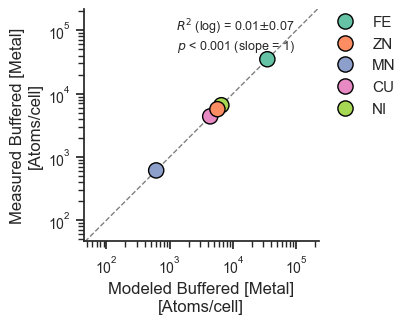

<Figure size 640x480 with 0 Axes>

In [48]:
# ── Buffer model (competition, Minimal) vs. measured buffered metal ───────────
# x: model estimate (atoms/cell), y: measured buffered metal (atoms/cell)

_model_lb = M_to_atoms(est_competition_minimal_lb, CELL_VOLUME_FL['Minimal'])
_model_ub = M_to_atoms(est_competition_minimal_ub, CELL_VOLUME_FL['Minimal'])
_meas_cnts = meas_buf_minimal['measured_M'].apply(
    lambda v: M_to_atoms(v, CELL_VOLUME_FL['Minimal'])
)
_meas_err_cnts = meas_buf_minimal['measured_std_M'].apply(
    lambda v: M_to_atoms(v, CELL_VOLUME_FL['Minimal'])
)

_common = sorted(
    set(_model_lb.index) & set(_meas_cnts.dropna().index) & set(TARGET_METALS)
)

_rows = []
for el in _common:
    lb = float(_model_lb[el])
    ub = float(_model_ub[el])
    meas = float(_meas_cnts[el])
    meas_err = float(_meas_err_cnts[el])
    if meas <= 0 or np.isnan(meas):
        continue
    _rows.append({
        'Element': el,
        'x_count': (lb + ub) / 2,
        'x_lb_count': lb,
        'x_ub_count': ub,
        'y_count': meas,
        'y_err_count': meas_err,
    })

_plot_df_buf = pd.DataFrame(_rows)

sns.set_theme(style="ticks")

_elements_buf = [
    e for e in ['FE', 'ZN', 'MN', 'CU', 'MO', 'NI', 'V', 'CO']
    if e in _plot_df_buf['Element'].values
]
_palette_buf = sns.color_palette("Set2", n_colors=len(_elements_buf))
_color_map_buf = dict(zip(_elements_buf, _palette_buf))



matplotlib.use('Agg')

fig2, ax2 = plt.subplots(figsize=(4.3,3.5))

_ref = np.logspace(0, 7, 300)
ax2.plot(_ref, _ref, ls="--", color="gray", lw=1, zorder=0)

sns.scatterplot(
    data=_plot_df_buf,
    x="y_count",
    y="y_count",
    hue="Element",
    palette="Set2",
    hue_order=_elements_buf,
    s=120,
    edgecolor="black",
    linewidth=1,
    ax=ax2,
    zorder=1,
)

# for _, row in _plot_df_buf.iterrows():
#     c = _color_map_buf[row["Element"]]
#     ax2.errorbar(
#         row["x_count"], row["y_count"],
#         xerr=[[row["x_count"] - row["x_lb_count"]],
#               [row["x_ub_count"] - row["x_count"]]],
#         yerr=row["y_err_count"],
#         fmt="none",
#         color='black',
#         capsize=3,
#         lw=0.8,
#         zorder=1,
#         elinewidth=1,
#     )

# for _, row in _plot_df_buf.iterrows():
#     ax2.annotate(
#         row["Element"],
#         xy=(row["x_count"], row["y_count"]),
#         xytext=(8, 8),
#         textcoords="offset points",
#         fontsize=9,
#     )

_log_x = np.log10(_plot_df_buf["x_count"])
_log_y = np.log10(_plot_df_buf["y_count"])
_slope, _intercept, _r_value, _p_fit, _std_err = stats.linregress(_log_x, _log_y)
_r_squared = _r_value ** 2
_t_stat = (_slope - 1) / _std_err
_p_slope1 = 2 * stats.t.sf(np.abs(_t_stat), df=len(_log_x) - 2)

_stats_text = (
    f"$R^2$ (log) = {_r_squared:.2f}" + r'$\pm$' + f'{_std_err:.2f} \n'
    f"{_fmt_p(_p_slope1)} (slope = 1)"
)
ax2.text(
    0.9, 0.97,
    _stats_text,
    transform=ax2.transAxes,
    ha="right", va="top",
    fontsize=9,
)

ax2.set_xscale("log")
ax2.set_yscale("log")
# ax2.xaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt))
# ax2.yaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt))
# ax2.xaxis.set_minor_formatter(ticker.ScalarFormatter())
# ax2.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))
# ax2.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))

# set axis tick params
ax2.tick_params(axis='both', which='major', labelsize=10)

ax2.set_xlabel("Modeled Buffered [Metal]\n[Atoms/cell]")
ax2.set_ylabel("Measured Buffered [Metal]\n[Atoms/cell]")
# ax2.set_title("Buffer Model vs. Measured Buffered Metal – Minimal Medium")

# set limits
plt.xlim(1e2, 1e5)
plt.ylim(1e2, 1e5)


# make sure x axis has log ticks


# set equal aspect
ax2.set_aspect('equal', adjustable='datalim')

ax2.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, frameon=False)

sns.despine()
plt.tight_layout()
%matplotlib inline
plt.show()

plt.savefig('notebooks/cofactors/buffer_figures/buffer_model_vs_measured_matplotlib.svg', dpi=300)


In [49]:

stability_pl = pl.from_pandas(stability.reset_index())

rich_vol = CELL_VOLUME_FL['Rich']
minimal_vol = CELL_VOLUME_FL['Minimal']

rich_factor = AVOGADRO * rich_vol * 1e-15
minimal_factor = AVOGADRO * minimal_vol * 1e-15


In [50]:
stability

,GLUTATHIONE[c],CYS[c],HIS[c],OXIDIZED-GLUTATHIONE[c],L-ASPARTATE[c],MET[c],L-ALPHA-ALANINE[c],LEU[c],VAL[c],GLY[c],TRP[c],ATP[c],CIT[c]
Element,,,,,,,,,,,,,
MG,NaN,2.75,NaN,NaN,2.40,NaN,1.96,NaN,NaN,1.66,NaN,4.03,3.44
MN,2.70,4.75,3.240000,NaN,3.91,2.77,2.43,2.30,2.32,2.27,2.54,4.76,3.79
FE,5.10,6.20,5.883093,NaN,4.34,3.24,3.54,3.42,3.39,NaN,NaN,5.18,4.56
CO,NaN,8.14,6.700000,NaN,5.90,4.17,4.32,4.49,4.24,4.64,4.47,4.60,4.90
NI,7.37,9.60,8.430000,9.08,7.16,5.27,5.26,5.33,5.09,5.59,5.35,4.86,5.30
CU,11.60,11.10,9.820000,13.37,8.75,7.68,7.94,7.97,7.96,7.99,8.01,6.34,8.22
ZN,7.98,9.11,6.350000,7.60,5.82,4.30,4.54,4.51,4.47,4.87,4.54,5.16,4.64


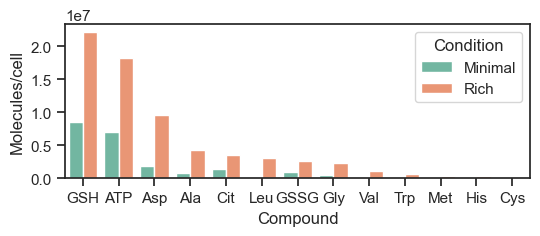

In [51]:
buffer_conc_df = pl.concat([pl.from_pandas(sim_buf_minimal.reset_index()).with_columns(pl.lit("Minimal").alias("Condition")),
 pl.from_pandas(sim_buf_rich.reset_index()).with_columns(pl.lit("Rich").alias("Condition"))]).rename({"index": "Compound", "conc_M": "Concentration (M)"})

renaming_dict = {"GLUTATHIONE[c]": "GSH", "CIT[c]": "Cit", "CYS[c]": "Cys", "HIS[c]": "His", "OXIDIZED-GLUTATHIONE[c]": "GSSG", "L-ASPARTATE[c]": "Asp", "L-GLUTAMATE[c]": "Glu", "LEU[c]": "Leu", "VAL[c]": "Val", "L-ALPHA-ALANINE[c]": "Ala",  "TRP[c]": "Trp", "ATP[c]": "ATP", "GLY[c]": "Gly", "MET[c]": "Met"}

metal_renaming_dict = {"FE": "Fe", "ZN": "Zn", "MN": "Mn", "CU": "Cu", "MO": "Mo", "NI": "Ni", "V": "V", "CO": "Co", "MG": "Mg"}

buffer_conc_df = buffer_conc_df.with_columns(pl.col("Compound").replace(renaming_dict))

# add a column for atoms/cell using rich_factor or minimal_factor depending on the condition
buffer_conc_df = buffer_conc_df.with_columns(
    pl.when(pl.col("Condition") == "Rich")
    .then(pl.col("Concentration (M)") * rich_factor)
    .otherwise(pl.col("Concentration (M)") * minimal_factor)
    .alias("Molecules/cell")
)

# get sorted order of compounds for plotting
compound_order = buffer_conc_df.filter(pl.col("Condition") == "Rich").sort("Concentration (M)", descending=True).select("Compound").to_series().to_list()

plt.figure(figsize=(6, 2))

# make a barplot of concentrations
sns.barplot(
    data=buffer_conc_df.to_pandas(),
    x="Compound",
    y="Molecules/cell",
    hue="Condition",
    palette="Set2",
    hue_order = ["Minimal", "Rich"],
    order=compound_order,
)

plt.savefig('notebooks/cofactors/figures/metabolite_concs.svg', dpi=300, transparent=True)

/var/folders/dx/0239zgvj0tgf46b5h8l7v_fc0000gn/T/ipykernel_14087/2648359655.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  stability_plot_df = pl.from_pandas(stability.reset_index()).unpivot(index=["Element"], variable_name="Compound", value_name="Stability constant").with_columns([pl.col("Compound").replace(renaming_dict),pl.col("Element").replace(metal_renaming_dict)]).pivot(index="Element", columns="Compound", values="Stability constant").select(["Element"] + compound_order)


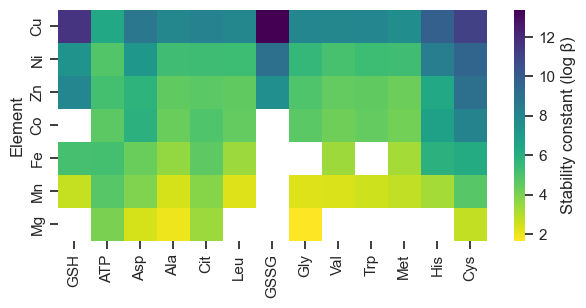

In [52]:
stability_plot_df = pl.from_pandas(stability.reset_index()).unpivot(index=["Element"], variable_name="Compound", value_name="Stability constant").with_columns([pl.col("Compound").replace(renaming_dict),pl.col("Element").replace(metal_renaming_dict)]).pivot(index="Element", columns="Compound", values="Stability constant").select(["Element"] + compound_order)

# get order of Compound sorted by mean value
stability_order = stability_plot_df.unpivot(index=["Element"], variable_name="Compound", value_name="Stability constant").group_by("Element").agg(pl.col("Stability constant").mean()).sort("Stability constant", descending=True).select("Element").to_series().to_list()

# create sorting column based on the mean stability constant per element
metal_index_dict = {metal: i for i, metal in enumerate(stability_order)}
stability_plot_df = stability_plot_df.with_columns(pl.col("Element").replace(metal_index_dict).alias("Order")).sort("Order").drop("Order")

plt.figure(figsize=(7., 3))

sns.heatmap(
    data=stability_plot_df.to_pandas().set_index("Element"),
    cmap="viridis_r",
    # annot=True,
    square=True,
    fmt=".1f",
    cbar_kws={"label": "Stability constant (log β)"},)

# save as svg
plt.savefig('notebooks/cofactors/figures/stability_heatmap.svg', dpi=300, transparent=True)

0 1.46e-20
0 2.56e-12
0 1.04e-11
0 2.42e-10
0 6.18e-08
0 2.08e-06
0 0.0027
0 4.5e-20
0 1.3e-13
0 9.4e-12
0 7e-11
0 1.9e-06
0 7e-06
0 0.001


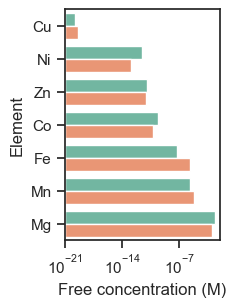

In [53]:
# create free concentration df

free_df = pl.concat([pl.from_pandas(free_metal_minimal.reset_index()).with_columns(pl.lit("Minimal").alias("Condition")),
           pl.from_pandas(free_metal_rich.reset_index()).with_columns(pl.lit("Rich").alias("Condition"))]).rename({"free_M": "Free concentration (M)"}).with_columns(pl.col("Element").replace(metal_renaming_dict))

# create barplot
plt.figure(figsize=(2,3 ))

sns.barplot(
    data=free_df.to_pandas(),
    y="Element",
    x="Free concentration (M)",
    hue="Condition",
    palette="Set2",
    hue_order=["Minimal", "Rich"],
    order=stability_order,
    legend=False
    # bottom=1e-21,  # set a minimum for the bars to start at (log scale will show this as a gap from zero)
    # linestyle="none",
    # dodge=0.5,
    # marker="D"
)

# adjust the "bottom" parameter of all bars to 1e-21
for patch in plt.gca().patches:
    
    # print x and width values
    print(patch.get_x(), patch.get_width())
    
    # set x to 1e-21 and width to original width + (original x - 1e-21)
    patch.set_x(1e-21)


    # patch.set_y(patch.get_y() + patch.get_height() * 0)  # keep original y position
    # patch.set_height(patch.get_height())  # keep original height
    # patch.set_x(patch.get_x() + patch.get_width() * 0)  # keep original x position
    # patch.set_width(patch.get_width())  # keep original width

# set xlim to 1e-21 to 1e-6
plt.xlim(1e-21, 1e-2)

# set log scale
plt.xscale("log")

# set bar drawing minimum to 1e-21 instead of zero 


# save as svg
plt.savefig('notebooks/cofactors/figures/free_metal_concs.svg', dpi=300,transparent=True)

# Deficit plots

In [54]:
deficit_minimal = (
    raw[raw['Medium'] == 'Minimal']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)
deficit_rich = (
    raw[raw['Medium'] == 'Rich']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)

In [61]:
raw

,Element,Atoms/cell (experiment),"Atoms/cell (experiment), stddev",Atoms/cell (simulation),"Atoms/cell (simulation), stddev",Medium,icp_M,sim_M,deficit_M,deficit_M_err
0,CU,87576.668290,29368.575624,15211.081627,1051.768662,Rich,4.731923e-05,8.218817e-06,3.910041e-05,1.587854e-05
1,MO,10797.032626,1000.000000,3444.940736,394.060051,Rich,5.833828e-06,1.861363e-06,3.972466e-06,5.807557e-07
2,NI,3240.269333,1000.000000,1284.841822,176.780770,Rich,1.750775e-06,6.942228e-07,1.056552e-06,5.486956e-07
3,ZN,399640.415582,88105.726872,357249.636639,22782.838522,Rich,2.159328e-04,1.930283e-04,2.290449e-05,4.917092e-05
4,CO,443.558908,100.000000,0.000000,0.000000,Rich,2.396627e-07,0.000000e+00,2.396627e-07,5.403177e-08
5,MN,46743.626407,12922.173275,69398.444095,3754.988890,Rich,2.525641e-05,3.749721e-05,-1.224080e-05,7.270888e-06
6,FE,607143.184501,128046.989721,494684.179294,34074.181705,Rich,3.280502e-04,2.672866e-04,6.076360e-05,7.159380e-05
9,FE,179978.374255,24669.603524,267598.232091,16974.659764,Minimal,2.061353e-04,3.064893e-04,-1.003540e-04,3.429750e-05
10,CU,7850.676467,1000.000000,8494.231262,862.443333,Minimal,8.991644e-06,9.728729e-06,-7.370850e-07,1.512451e-06
11,CO,520.075813,1000.000000,0.000000,0.000000,Minimal,5.956603e-07,0.000000e+00,5.956603e-07,1.145334e-06


In [83]:
deficit_plot_df = pl.concat([pl.from_pandas((deficit_minimal * minimal_factor).reset_index()).filter(pl.col("Element").is_in(["NI", "CO"]))
                            .with_columns(pl.lit("Minimal").alias("Medium")), 
                             pl.from_pandas((deficit_rich * rich_factor).reset_index()).filter(pl.col("Element").is_in(["NI", "CO"]))
                            .with_columns(pl.lit("Rich").alias("Medium"))
           ])

# rename icp_M to Atoms/cell (experiment) and sim_M to Atoms/cell (simulation), and deficit to Atoms/cell (deficit)
deficit_plot_df = deficit_plot_df.rename({"icp_M": "Atoms/cell (experiment)", "sim_M": "Atoms/cell (simulation)", "deficit_M": "Atoms/cell (deficit)", "deficit_M_err": "Atoms/cell (deficit error)"})

# join with raw stddev cols on Element and Medium 
deficit_plot_df = deficit_plot_df.join(
    pl.from_pandas(raw).select("Element", "Medium", "Atoms/cell (experiment), stddev", "Atoms/cell (simulation), stddev"), on=["Element", "Medium"], how="left"

)

# set experiment stddev to 0
deficit_plot_df = deficit_plot_df.with_columns(pl.col("Atoms/cell (experiment), stddev") * 0)

deficit_plot_df

Element,Atoms/cell (experiment),Atoms/cell (simulation),Atoms/cell (deficit),Atoms/cell (deficit error),Medium,"Atoms/cell (experiment), stddev","Atoms/cell (simulation), stddev"
str,f64,f64,f64,f64,str,f64,f64
"""CO""",520.075813,0.0,520.075813,1000.0,"""Minimal""",0.0,0.0
"""NI""",3780.077086,684.082189,3095.994897,1007.873955,"""Minimal""",0.0,125.737464
"""NI""",3240.269333,1284.841822,1955.427511,1015.50551,"""Rich""",0.0,176.78077
"""CO""",443.558908,0.0,443.558908,100.0,"""Rich""",0.0,0.0


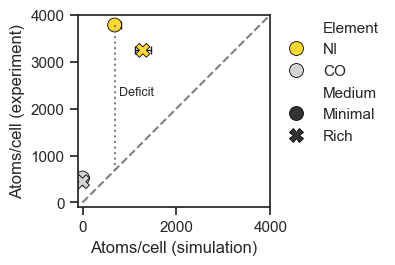

In [106]:
# scatter simulation vs experiment 
plt.figure(figsize=(3, 2.5))

# set colors to colors 6 and 7 from Set2
palette = [sns.color_palette("Set2")[5], "lightgray"]

g = sns.scatterplot(
    data=deficit_plot_df.to_pandas(),
    x="Atoms/cell (simulation)",
    y="Atoms/cell (experiment)",
    hue="Element",
    palette=palette,
    hue_order=["NI", "CO"],
    style="Medium",
    s=100,
    edgecolor="black",
    linewidth=0.6,
)

# add error bars
for _, row in deficit_plot_df.to_pandas().iterrows():
    c = palette[0] if row["Element"] == "NI" else palette[1]
    plt.errorbar(
        row["Atoms/cell (simulation)"],
        row["Atoms/cell (experiment)"],
        xerr=row["Atoms/cell (simulation), stddev"],
        yerr=row["Atoms/cell (experiment), stddev"],
        fmt="none",
        color="k",
        capsize=3,
        lw=1,
        zorder=-1,
    )

# move legend out
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, frameon=False)

# set axis lims to 0, 4000
plt.xlim(-100, 4000)
plt.ylim(-100, 4000)

# set equal aspect ratio
plt.gca().set_aspect('equal', adjustable='box')

# make y=x line
plt.plot([0, 4000], [0, 4000], ls="--", color="gray")

# add vertical line from NI point to xy line
ni_value_sim = deficit_plot_df.filter(pl.col("Element") == "NI").select("Atoms/cell (simulation)").to_series().to_list()[0]
ni_value_exp = deficit_plot_df.filter(pl.col("Element") == "NI").select("Atoms/cell (experiment)").to_series().to_list()[0]
plt.plot([ni_value_sim, ni_value_sim], [ni_value_exp, ni_value_sim], ls=":", color="gray")

# annotate with "deficit"
plt.annotate(
    "Deficit",
    xy=(ni_value_sim, ni_value_exp),
    xytext=(ni_value_sim + 100, ni_value_exp - 1500),
    # arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9,
)

# save as svg
plt.savefig('notebooks/cofactors/figures/simulation_vs_experiment_scatter.svg', dpi=300, transparent=True)

In [100]:
deficit_plot_df.filter(pl.col("Element") == "NI").to_pandas().iloc[0]

Element                                     NI
Atoms/cell (experiment)            3780.077086
Atoms/cell (simulation)             684.082189
Atoms/cell (deficit)               3095.994897
Atoms/cell (deficit error)         1007.873955
Medium                                 Minimal
Atoms/cell (experiment), stddev            0.0
Atoms/cell (simulation), stddev     125.737464
Name: 0, dtype: object

In [85]:
deficit_plot_df

Element,Atoms/cell (experiment),Atoms/cell (simulation),Atoms/cell (deficit),Atoms/cell (deficit error),Medium,"Atoms/cell (experiment), stddev","Atoms/cell (simulation), stddev"
str,f64,f64,f64,f64,str,f64,f64
"""CO""",520.075813,0.0,520.075813,1000.0,"""Minimal""",0.0,0.0
"""NI""",3780.077086,684.082189,3095.994897,1007.873955,"""Minimal""",0.0,125.737464
"""NI""",3240.269333,1284.841822,1955.427511,1015.50551,"""Rich""",0.0,176.78077
"""CO""",443.558908,0.0,443.558908,100.0,"""Rich""",0.0,0.0


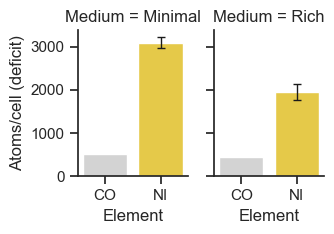

In [107]:
# make a bar plot of deficit
# plt.figure(figsize=(3, 2.5))

sns.catplot(
    data=deficit_plot_df.to_pandas(),
    x="Element",
    y="Atoms/cell (deficit)",
    hue="Element",
    kind="bar", col="Medium",
    palette=palette,
    hue_order=["NI", "CO"],
    height=2.5, aspect=0.7
)

# for NI bars, add simulation error as error bar
for ax, medium in zip(plt.gcf().axes, ["Minimal", "Rich"]):
    subset = deficit_plot_df.filter(pl.col("Medium") == medium).to_pandas()
    for _, row in subset.iterrows():
        if row["Element"] == "NI":
            ax.errorbar(
                row["Element"],
                row["Atoms/cell (deficit)"],
                yerr=row["Atoms/cell (simulation), stddev"],
                fmt="none",
                color="k",
                capsize=3,
                lw=1,
            )
            
# save as svg
plt.savefig('notebooks/cofactors/figures/deficit_barplot.svg', dpi=300, transparent=True)

# Calculate buffered amounts

In [58]:
buffer_ar_df = buffer_conc_df.pivot(index="Compound", columns="Condition", values="Molecules/cell")

# add col for compound_order to sort
compound_order_dict = {comp: i for i, comp in enumerate(compound_order)}

buffer_ar = buffer_ar_df.with_columns(pl.col("Compound").replace(compound_order_dict).alias("Order")).sort("Order").drop(["Order", "Compound"]).to_numpy()

buffer_ar

/var/folders/dx/0239zgvj0tgf46b5h8l7v_fc0000gn/T/ipykernel_14087/4261073043.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  buffer_ar_df = buffer_conc_df.pivot(index="Compound", columns="Condition", values="Molecules/cell")


array([[8.54805735e+06, 2.21946037e+07],
       [6.99981228e+06, 1.81746627e+07],
       [5.89980566e+04, 3.06371090e+05],
       [5.32557488e+04, 2.76551809e+05],
       [1.57732005e+04, 8.19086469e+04],
       [1.84117595e+06, 9.56104272e+06],
       [8.10950900e+05, 4.21118700e+06],
       [1.33381678e+06, 3.46318857e+06],
       [1.10485089e+05, 3.10299782e+06],
       [9.79464907e+05, 2.54313166e+06],
       [4.53206949e+05, 2.35345842e+06],
       [2.21697078e+05, 1.15125070e+06],
       [1.57732005e+04, 6.94749424e+05]])

In [59]:
stability_plot_df.drop("Element").to_numpy()

# fill nan with 0
np.nan_to_num(stability_plot_df.drop("Element").to_numpy())

array([[11.6       ,  6.34      ,  8.75      ,  7.94      ,  8.22      ,
         7.97      , 13.37      ,  7.99      ,  7.96      ,  8.01      ,
         7.68      ,  9.82      , 11.1       ],
       [ 7.37      ,  4.86      ,  7.16      ,  5.26      ,  5.3       ,
         5.33      ,  9.08      ,  5.59      ,  5.09      ,  5.35      ,
         5.27      ,  8.43      ,  9.6       ],
       [ 7.98      ,  5.16      ,  5.82      ,  4.54      ,  4.64      ,
         4.51      ,  7.6       ,  4.87      ,  4.47      ,  4.54      ,
         4.3       ,  6.35      ,  9.11      ],
       [ 0.        ,  4.6       ,  5.9       ,  4.32      ,  4.9       ,
         4.49      ,  0.        ,  4.64      ,  4.24      ,  4.47      ,
         4.17      ,  6.7       ,  8.14      ],
       [ 5.1       ,  5.18      ,  4.34      ,  3.54      ,  4.56      ,
         3.42      ,  0.        ,  0.        ,  3.39      ,  0.        ,
         3.24      ,  5.88309336,  6.2       ],
       [ 2.7       ,  4.76    

In [60]:
np.nan_to_num(10 ** stability_plot_df.drop("Element").to_numpy()) @ buffer_ar

array([[2.24175280e+19, 1.07652896e+20],
       [1.30043075e+15, 8.66955554e+15],
       [8.70691830e+14, 3.18844199e+15],
       [3.76897266e+12, 1.03261654e+14],
       [2.33792619e+12, 7.57313115e+12],
       [4.10190033e+11, 1.10657384e+12],
       [7.51372967e+10, 1.95621778e+11]])